In [47]:
# Import pandas for data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import train_test_split for dividing the dataset
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Import XGBoost
from xgboost import XGBClassifier

# Import SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [48]:
# URL of the credit card fraud dataset
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

# Load the dataset directly from the URL
df = pd.read_csv(url)

print("=" * 60)
print("CREDIT CARD FRAUD DATASET")
print("=" * 60)

print(f"Dataset shape: {df.shape}")

print("\nColumn names:")
print(df.columns.tolist())

CREDIT CARD FRAUD DATASET
Dataset shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [49]:
# Display the first five rows
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)

display(df.head())

# Display the data types
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

# Display statistical summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

display(df.describe())

FIRST 5 ROWS


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



DATA TYPES
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

MISSING VALUES
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

STATISTICAL SU

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759088e-12,-8.251210e-13,-9.655224e-13,8.321417e-13,1.650335e-13,4.248462e-13,-3.054652e-13,8.777941e-14,-1.179734e-12,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [50]:
# Count the number of transactions in each class
class_counts = df["Class"].value_counts()

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print(class_counts)

# Calculate the percentage of fraud transactions
fraud_percentage = df["Class"].mean() * 100

# Calculate the percentage of non-fraud transactions
non_fraud_percentage = 100 - fraud_percentage

print(f"\nFraud transactions: {df['Class'].sum():,}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")

print(f"\nNon-fraud transactions: {len(df) - df['Class'].sum():,}")
print(f"Non-fraud percentage: {non_fraud_percentage:.4f}%")

CLASS DISTRIBUTION
Class
0    284315
1       492
Name: count, dtype: int64

Fraud transactions: 492
Fraud percentage: 0.1727%

Non-fraud transactions: 284,315
Non-fraud percentage: 99.8273%


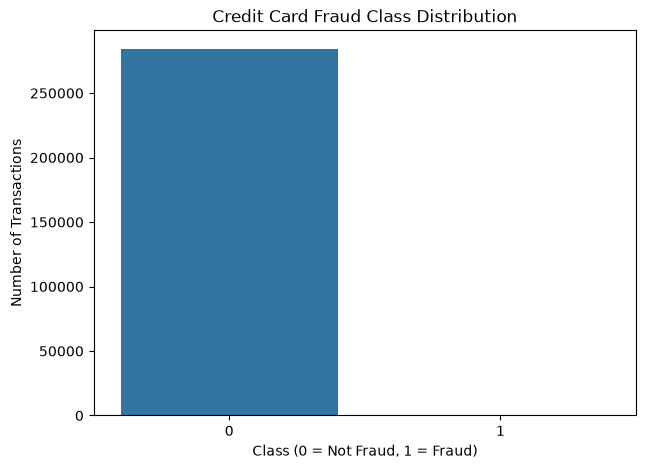

In [51]:
# Plot the number of transactions in each class
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Credit Card Fraud Class Distribution")
plt.xlabel("Class (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [52]:
# X contains the input features
# We remove the target column "Class"
X = df.drop("Class", axis=1)

# y contains the target variable
y = df["Class"]

print("=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"Number of features: {X.shape[1]}")
print(f"Target variable: Class")

FEATURES AND TARGET
Features shape: (284807, 30)
Target shape: (284807,)
Number of features: 30
Target variable: Class


In [55]:
# Set random state so results are reproducible
RANDOM_STATE = 42

# Split the data into training and testing sets
# Stratify keeps the same fraud/non-fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

print(f"\nTraining fraud percentage: {y_train.mean():.4%}")
print(f"Testing fraud percentage: {y_test.mean():.4%}")

DATA SPLIT
Training set: (227845, 30)
Testing set: (56962, 30)

Training fraud percentage: 0.1729%
Testing fraud percentage: 0.1720%


In [56]:
# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

FEATURE SCALING
Scaled training data shape: (227845, 30)
Scaled testing data shape: (56962, 30)


In [57]:
# Create the SMOTE object
smote = SMOTE(
    random_state=RANDOM_STATE
)

# Apply SMOTE ONLY to the training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("=" * 60)
print("SMOTE RESULTS")
print("=" * 60)

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nBefore SMOTE:")
print(f"Training samples: {len(y_train):,}")

print("\nAfter SMOTE:")
print(f"Training samples: {len(y_train_smote):,}")

SMOTE RESULTS
Class distribution BEFORE SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Before SMOTE:
Training samples: 227,845

After SMOTE:
Training samples: 454,902


In [58]:
# Create a dataframe showing the class distribution
smote_distribution = pd.DataFrame({
    "Class": ["Not Fraud", "Fraud"],
    "Before SMOTE": [
        (y_train == 0).sum(),
        (y_train == 1).sum()
    ],
    "After SMOTE": [
        (y_train_smote == 0).sum(),
        (y_train_smote == 1).sum()
    ]
})

# Display the results
display(smote_distribution)

,Class,Before SMOTE,After SMOTE
0,Not Fraud,227451,227451
1,Fraud,394,227451


In [59]:
# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train Logistic Regression using SMOTE-balanced training data
logistic_model.fit(
    X_train_smote,
    y_train_smote
)

# Generate probability predictions
# We need probabilities for threshold tuning
y_proba_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [60]:
# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

# Train Random Forest
# Random Forest does not require scaling,
# but using the same SMOTE training data is fine
random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

# Generate probability predictions
y_proba_rf = random_forest_model.predict_proba(
    X_test_scaled
)[:, 1]

In [61]:
# Calculate the ratio between non-fraud and fraud cases
# This helps XGBoost pay more attention to the minority class
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

# Train XGBoost using the SMOTE-balanced data
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Generate probability predictions
y_proba_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:, 1]

In [62]:
# This function converts probabilities into class predictions
# using a chosen threshold.
def predict_with_threshold(probabilities, threshold):
    
    # Probability >= threshold becomes class 1
    # Probability < threshold becomes class 0
    return (probabilities >= threshold).astype(int)

In [63]:
# Define thresholds that we want to test
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

# Store results here
lr_threshold_results = []

# Test every threshold
for threshold in thresholds:

    # Convert probabilities into predictions
    predictions = predict_with_threshold(
        y_proba_lr,
        threshold
    )

    # Calculate metrics
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    # Store the results
    lr_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert results into DataFrame
lr_threshold_df = pd.DataFrame(
    lr_threshold_results
)

print("=" * 60)
print("LOGISTIC REGRESSION THRESHOLD ANALYSIS")
print("=" * 60)

display(lr_threshold_df.round(4))

LOGISTIC REGRESSION THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.10,0.8045,0.0083,0.9490,0.0164
1,0.15,0.8659,0.0119,0.9388,0.0235
2,0.20,0.9041,0.0162,0.9184,0.0319
3,0.25,0.9278,0.0215,0.9184,0.0419
4,0.30,0.9441,0.0276,0.9184,0.0535
5,0.35,0.9552,0.0342,0.9184,0.0659
6,0.40,0.9634,0.0415,0.9184,0.0795
7,0.45,0.9693,0.0491,0.9184,0.0933
8,0.50,0.9741,0.0578,0.9184,0.1088
9,0.55,0.9777,0.0666,0.9184,0.1242


In [64]:
# Find the row with the highest F1-score
best_lr_row = lr_threshold_df.loc[
    lr_threshold_df["F1-Score"].idxmax()
]

# Extract the best threshold
best_lr_threshold = best_lr_row["Threshold"]

print("=" * 60)
print("BEST LOGISTIC REGRESSION THRESHOLD")
print("=" * 60)

print(f"Best threshold: {best_lr_threshold:.2f}")
print(f"Accuracy: {best_lr_row['Accuracy']:.4f}")
print(f"Precision: {best_lr_row['Precision']:.4f}")
print(f"Recall: {best_lr_row['Recall']:.4f}")
print(f"F1-Score: {best_lr_row['F1-Score']:.4f}")

BEST LOGISTIC REGRESSION THRESHOLD
Best threshold: 0.90
Accuracy: 0.9934
Precision: 0.1916
Recall: 0.8878
F1-Score: 0.3152


In [65]:
# Store Random Forest threshold results
rf_threshold_results = []

# Test each threshold
for threshold in thresholds:

    # Convert probabilities to predictions
    predictions = predict_with_threshold(
        y_proba_rf,
        threshold
    )

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    # Store results
    rf_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert to DataFrame
rf_threshold_df = pd.DataFrame(
    rf_threshold_results
)

print("=" * 60)
print("RANDOM FOREST THRESHOLD ANALYSIS")
print("=" * 60)

display(rf_threshold_df.round(4))

RANDOM FOREST THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.10,0.9958,0.2785,0.8980,0.4251
1,0.15,0.9982,0.4889,0.8980,0.6331
2,0.20,0.9988,0.5946,0.8980,0.7154
3,0.25,0.9990,0.6641,0.8878,0.7598
4,0.30,0.9992,0.7083,0.8673,0.7798
5,0.35,0.9993,0.7568,0.8571,0.8038
6,0.40,0.9994,0.8119,0.8367,0.8241
7,0.45,0.9994,0.8351,0.8265,0.8308
8,0.50,0.9995,0.8681,0.8061,0.8360
9,0.55,0.9995,0.8778,0.8061,0.8404


In [66]:
# Find the threshold with the highest F1-score
best_rf_row = rf_threshold_df.loc[
    rf_threshold_df["F1-Score"].idxmax()
]

# Store the best threshold
best_rf_threshold = best_rf_row["Threshold"]

print("=" * 60)
print("BEST RANDOM FOREST THRESHOLD")
print("=" * 60)

print(f"Best threshold: {best_rf_threshold:.2f}")
print(f"Accuracy: {best_rf_row['Accuracy']:.4f}")
print(f"Precision: {best_rf_row['Precision']:.4f}")
print(f"Recall: {best_rf_row['Recall']:.4f}")
print(f"F1-Score: {best_rf_row['F1-Score']:.4f}")

BEST RANDOM FOREST THRESHOLD
Best threshold: 0.70
Accuracy: 0.9996
Precision: 0.9506
Recall: 0.7857
F1-Score: 0.8603


In [67]:
# Store XGBoost threshold results
xgb_threshold_results = []

# Test each threshold
for threshold in thresholds:

    # Convert probabilities to predictions
    predictions = predict_with_threshold(
        y_proba_xgb,
        threshold
    )

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    # Store results
    xgb_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert to DataFrame
xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

print("=" * 60)
print("XGBOOST THRESHOLD ANALYSIS")
print("=" * 60)

display(xgb_threshold_df.round(4))

XGBOOST THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.10,0.9579,0.0355,0.8980,0.0684
1,0.15,0.9727,0.0538,0.8980,0.1016
2,0.20,0.9804,0.0735,0.8980,0.1359
3,0.25,0.9852,0.0946,0.8878,0.1709
4,0.30,0.9883,0.1162,0.8776,0.2053
5,0.35,0.9907,0.1424,0.8776,0.2450
6,0.40,0.9929,0.1788,0.8776,0.2971
7,0.45,0.9943,0.2145,0.8776,0.3447
8,0.50,0.9953,0.2522,0.8776,0.3918
9,0.55,0.9961,0.2911,0.8673,0.4359


In [68]:
# Store XGBoost threshold results
xgb_threshold_results = []

# Test each threshold
for threshold in thresholds:

    # Convert probabilities to predictions
    predictions = predict_with_threshold(
        y_proba_xgb,
        threshold
    )

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    # Store results
    xgb_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert to DataFrame
xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

print("=" * 60)
print("XGBOOST THRESHOLD ANALYSIS")
print("=" * 60)

display(xgb_threshold_df.round(4))

XGBOOST THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.10,0.9579,0.0355,0.8980,0.0684
1,0.15,0.9727,0.0538,0.8980,0.1016
2,0.20,0.9804,0.0735,0.8980,0.1359
3,0.25,0.9852,0.0946,0.8878,0.1709
4,0.30,0.9883,0.1162,0.8776,0.2053
5,0.35,0.9907,0.1424,0.8776,0.2450
6,0.40,0.9929,0.1788,0.8776,0.2971
7,0.45,0.9943,0.2145,0.8776,0.3447
8,0.50,0.9953,0.2522,0.8776,0.3918
9,0.55,0.9961,0.2911,0.8673,0.4359


In [69]:
# Find the threshold with the highest F1-score
best_xgb_row = xgb_threshold_df.loc[
    xgb_threshold_df["F1-Score"].idxmax()
]

# Store the best threshold
best_xgb_threshold = best_xgb_row["Threshold"]

print("=" * 60)
print("BEST XGBOOST THRESHOLD")
print("=" * 60)

print(f"Best threshold: {best_xgb_threshold:.2f}")
print(f"Accuracy: {best_xgb_row['Accuracy']:.4f}")
print(f"Precision: {best_xgb_row['Precision']:.4f}")
print(f"Recall: {best_xgb_row['Recall']:.4f}")
print(f"F1-Score: {best_xgb_row['F1-Score']:.4f}")

BEST XGBOOST THRESHOLD
Best threshold: 0.90
Accuracy: 0.9990
Precision: 0.6777
Recall: 0.8367
F1-Score: 0.7489


In [70]:
# Create predictions using the best threshold for each model

y_pred_lr = predict_with_threshold(
    y_proba_lr,
    best_lr_threshold
)

y_pred_rf = predict_with_threshold(
    y_proba_rf,
    best_rf_threshold
)

y_pred_xgb = predict_with_threshold(
    y_proba_xgb,
    best_xgb_threshold
)

In [71]:
# Create a function to calculate all important metrics
def calculate_metrics(y_true, y_pred, probabilities):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }


# Calculate Logistic Regression metrics
lr_metrics = calculate_metrics(
    y_test,
    y_pred_lr,
    y_proba_lr
)

# Calculate Random Forest metrics
rf_metrics = calculate_metrics(
    y_test,
    y_pred_rf,
    y_proba_rf
)

# Calculate XGBoost metrics
xgb_metrics = calculate_metrics(
    y_test,
    y_pred_xgb,
    y_proba_xgb
)

In [72]:
# Create a comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Threshold": [
        best_lr_threshold,
        best_rf_threshold,
        best_xgb_threshold
    ],

    "Accuracy": [
        lr_metrics["Accuracy"],
        rf_metrics["Accuracy"],
        xgb_metrics["Accuracy"]
    ],

    "Precision": [
        lr_metrics["Precision"],
        rf_metrics["Precision"],
        xgb_metrics["Precision"]
    ],

    "Recall": [
        lr_metrics["Recall"],
        rf_metrics["Recall"],
        xgb_metrics["Recall"]
    ],

    "F1-Score": [
        lr_metrics["F1-Score"],
        rf_metrics["F1-Score"],
        xgb_metrics["F1-Score"]
    ],

    "ROC-AUC": [
        lr_metrics["ROC-AUC"],
        rf_metrics["ROC-AUC"],
        xgb_metrics["ROC-AUC"]
    ]
})

# Sort models by F1-score
results = results.sort_values(
    "F1-Score",
    ascending=False
)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(results.round(4))

MODEL COMPARISON


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.7,0.9996,0.9506,0.7857,0.8603,0.9734
2,XGBoost,0.9,0.9990,0.6777,0.8367,0.7489,0.9799
0,Logistic Regression,0.9,0.9934,0.1916,0.8878,0.3152,0.9708


In [73]:
# Find the model with the highest F1-score
best_model_row = results.iloc[0]

best_model = best_model_row["Model"]
best_threshold = best_model_row["Threshold"]
best_f1 = best_model_row["F1-Score"]
best_precision = best_model_row["Precision"]
best_recall = best_model_row["Recall"]
best_accuracy = best_model_row["Accuracy"]
best_roc_auc = best_model_row["ROC-AUC"]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model: {best_model}")
print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print(f"F1-Score: {best_f1:.4f}")
print(f"ROC-AUC: {best_roc_auc:.4f}")

BEST MODEL
Model: Random Forest
Threshold: 0.70
Accuracy: 0.9996
Precision: 0.9506
Recall: 0.7857
F1-Score: 0.8603
ROC-AUC: 0.9734


In [74]:
# Select the predictions belonging to the best model

if best_model == "Logistic Regression":

    best_pred = y_pred_lr
    best_proba = y_proba_lr

elif best_model == "Random Forest":

    best_pred = y_pred_rf
    best_proba = y_proba_rf

else:

    best_pred = y_pred_xgb
    best_proba = y_proba_xgb


print(f" Selected {best_model} as the best model.")
print(f" Optimized threshold: {best_threshold:.2f}")

 Selected Random Forest as the best model.
 Optimized threshold: 0.70


In [75]:
# Calculate confusion matrix
cm = confusion_matrix(
    y_test,
    best_pred
)

# Convert confusion matrix to a readable DataFrame
cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual: Not Fraud",
        "Actual: Fraud"
    ],
    columns=[
        "Predicted: Not Fraud",
        "Predicted: Fraud"
    ]
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

display(cm_df)

CONFUSION MATRIX


,Predicted: Not Fraud,Predicted: Fraud
Actual: Not Fraud,56860,4
Actual: Fraud,21,77


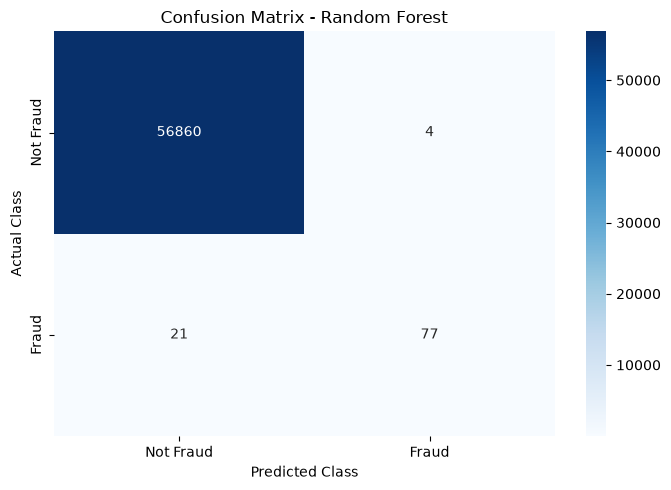

In [76]:
# Plot the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    f"Confusion Matrix - {best_model}"
)

plt.tight_layout()
plt.show()

In [77]:
# Generate a detailed classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        best_pred,
        target_names=[
            "Not Fraud",
            "Fraud"
        ],
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.95      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



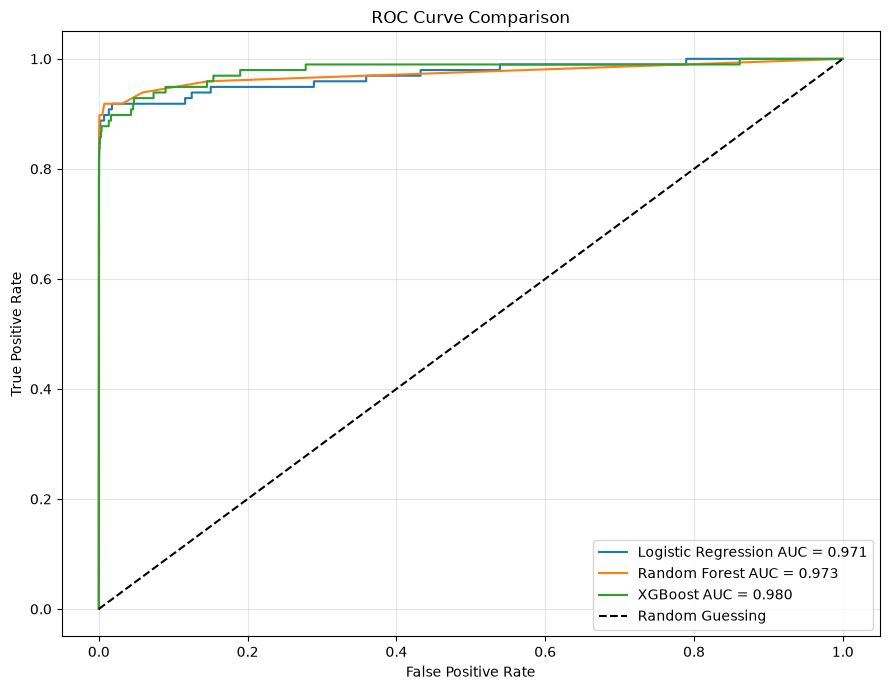

In [78]:
# Calculate ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_proba_lr
)

# Calculate ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_proba_rf
)

# Calculate ROC curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_proba_xgb
)

# Plot all ROC curves
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression AUC = {lr_metrics['ROC-AUC']:.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC = {rf_metrics['ROC-AUC']:.3f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost AUC = {xgb_metrics['ROC-AUC']:.3f}"
)

# Random guessing baseline
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Guessing"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

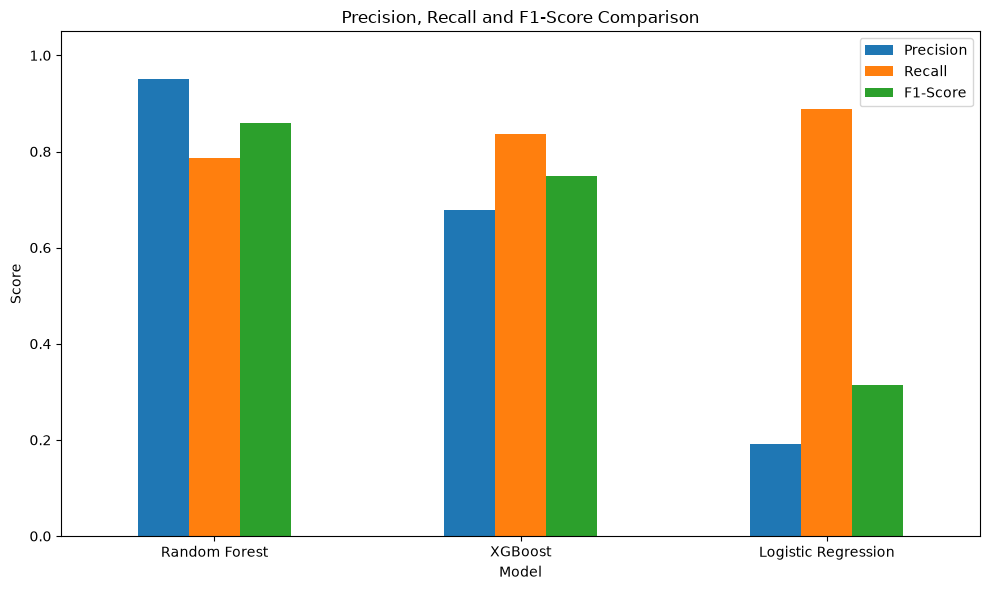

In [79]:
# Select metrics that are especially important for fraud detection
metric_comparison = results[
    [
        "Model",
        "Precision",
        "Recall",
        "F1-Score"
    ]
]

# Convert model names into index for plotting
metric_comparison.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Precision, Recall and F1-Score Comparison"
)

plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(
    rotation=0
)

plt.ylim(
    0,
    1.05
)

plt.tight_layout()
plt.show()

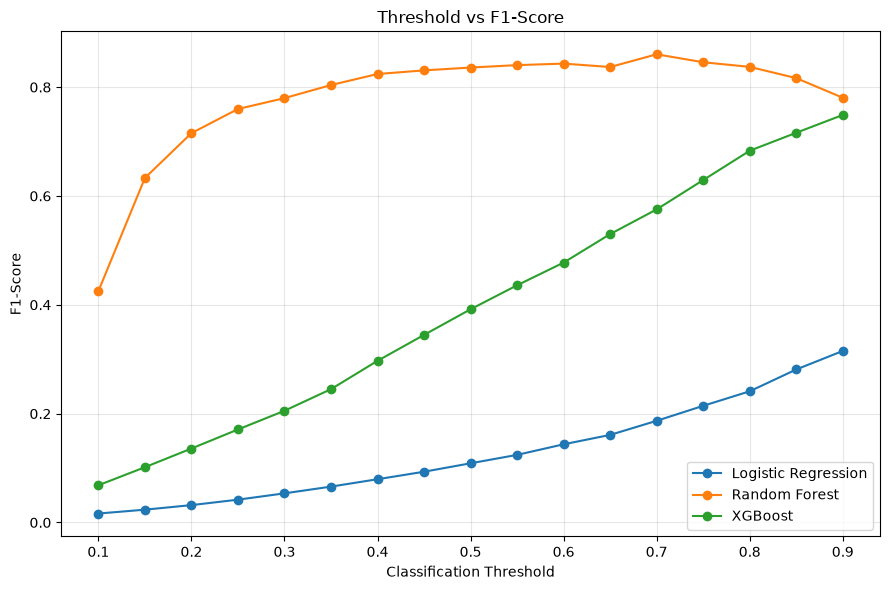

In [80]:
# Plot Logistic Regression F1 scores
plt.figure(figsize=(9, 6))

plt.plot(
    lr_threshold_df["Threshold"],
    lr_threshold_df["F1-Score"],
    marker="o",
    label="Logistic Regression"
)

# Plot Random Forest F1 scores
plt.plot(
    rf_threshold_df["Threshold"],
    rf_threshold_df["F1-Score"],
    marker="o",
    label="Random Forest"
)

# Plot XGBoost F1 scores
plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["F1-Score"],
    marker="o",
    label="XGBoost"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1-Score")

plt.title(
    "Threshold vs F1-Score"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [81]:
# Feature importance is available for Random Forest and XGBoost

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).head(10)

print("=" * 60)
print("TOP 10 RANDOM FOREST FEATURES")
print("=" * 60)

display(rf_importance)

TOP 10 RANDOM FOREST FEATURES


,Feature,Importance
14,V14,0.190226
10,V10,0.113001
4,V4,0.111806
12,V12,0.092622
17,V17,0.083424
3,V3,0.062034
11,V11,0.054921
16,V16,0.043010
2,V2,0.038964
9,V9,0.026735


In [82]:
# Extract XGBoost feature importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort features from most important to least important
xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
).head(10)

print("=" * 60)
print("TOP 10 XGBOOST FEATURES")
print("=" * 60)

display(xgb_importance)

TOP 10 XGBOOST FEATURES


,Feature,Importance
14,V14,0.549221
4,V4,0.048621
8,V8,0.034884
12,V12,0.033227
13,V13,0.019593
10,V10,0.018363
3,V3,0.017803
18,V18,0.017782
29,Amount,0.017315
1,V1,0.016203


In [83]:
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(f"Best Model: {best_model}")
print(f"Best Threshold: {best_threshold:.2f}")

print("\nPerformance:")
print(f"Accuracy:  {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"F1-Score:  {best_f1:.4f}")
print(f"ROC-AUC:   {best_roc_auc:.4f}")

FINAL RESULTS
Best Model: Random Forest
Best Threshold: 0.70

Performance:
Accuracy:  0.9996
Precision: 0.9506
Recall:    0.7857
F1-Score:  0.8603
ROC-AUC:   0.9734


In [84]:
print("=" * 60)
print("CONCLUSION")
print("=" * 60)

print(f" Best model: {best_model}")
print(f" Best threshold: {best_threshold:.2f}")
print(f" F1-score: {best_f1:.4f}")
print(f" Precision: {best_precision:.4f}")
print(f" Recall: {best_recall:.4f}")
print(f" ROC-AUC: {best_roc_auc:.4f}")

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print("""
1. The dataset is highly imbalanced because fraudulent
   transactions represent only a very small percentage
   of all transactions.

2. SMOTE was applied only to the training data to improve
   the model's ability to learn the minority fraud class.

3. Three classification models were compared:
   Logistic Regression, Random Forest and XGBoost.

4. Different probability thresholds were tested instead
   of automatically using the default threshold of 0.50.

5. F1-score was used as the main metric because it balances
   precision and recall.

6. Recall is important because missing a fraudulent
   transaction can result in financial loss.

7. Precision is important because too many false fraud
   alerts can inconvenience legitimate customers.

8. The final model was selected based on the highest
   F1-score rather than accuracy alone.
""")

print("=" * 60)
print("ASSIGNMENT COMPLETE")
print("=" * 60)

CONCLUSION
 Best model: Random Forest
 Best threshold: 0.70
 F1-score: 0.8603
 Precision: 0.9506
 Recall: 0.7857
 ROC-AUC: 0.9734

KEY INSIGHTS

1. The dataset is highly imbalanced because fraudulent
   transactions represent only a very small percentage
   of all transactions.

2. SMOTE was applied only to the training data to improve
   the model's ability to learn the minority fraud class.

3. Three classification models were compared:
   Logistic Regression, Random Forest and XGBoost.

4. Different probability thresholds were tested instead
   of automatically using the default threshold of 0.50.

5. F1-score was used as the main metric because it balances
   precision and recall.

6. Recall is important because missing a fraudulent
   transaction can result in financial loss.

7. Precision is important because too many false fraud
   alerts can inconvenience legitimate customers.

8. The final model was selected based on the highest
   F1-score rather than accuracy alone.

ASSIGNM